# Kernel polinomial em círculos concêntricos

**Autor:** Prof. Dr. Sergio Antônio Andrade de Freitas  
**Material da disciplina:** FGA0083 — Aprendizado de Máquina, UnB

## Objetivo e dados

Comparar graus 2 e 3 na mesma amostra.

**Pergunta-guia:** Por que grau 2 separa melhor este padrão radial?

Execute as células na ordem e interprete os resultados antes de fazer o exercício.

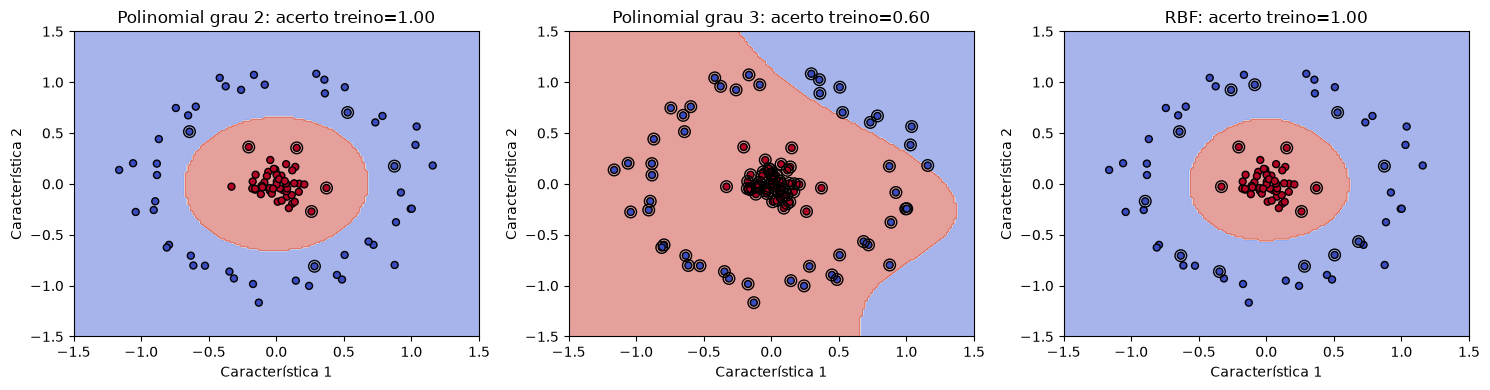

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.svm import SVC

X, y = make_circles(n_samples=100, factor=0.1, noise=0.1, random_state=42)
xx, yy = np.meshgrid(np.linspace(-1.5, 1.5, 160), np.linspace(-1.5, 1.5, 160))
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (titulo, modelo) in zip(axes, [
    ('Polinomial grau 2', SVC(kernel='poly', degree=2)),
    ('Polinomial grau 3', SVC(kernel='poly', degree=3)),
    ('RBF', SVC(kernel='rbf')),
]):
    modelo.fit(X, y)
    Z = modelo.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.5, cmap='coolwarm')
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='k', s=25)
    ax.scatter(modelo.support_vectors_[:, 0], modelo.support_vectors_[:, 1],
               s=70, facecolors='none', edgecolors='black')
    ax.set_title(f'{titulo}: acerto treino={modelo.score(X, y):.2f}')
    ax.set_xlabel('Característica 1')
    ax.set_ylabel('Característica 2')
plt.tight_layout()
plt.show()

## Interpretação e limites

A comparação de ajuste no treino é uma demonstração geométrica, não uma avaliação de generalização.

## Exercício

Repita com uma divisão treino/teste e compare com RBF.

Registre a hipótese, a mudança realizada, a métrica ou figura observada e uma conclusão que os dados de fato sustentem.